In [1]:
using LinearAlgebra
using Random
using Plots

plotly()

n = 100

# ГЕНЕРАЦИЯ МАТРИЦ
A = rand(1.0:350.0, n, n)
A += Diagonal(vec(sum(A, dims = 2)))
b = Float64.(rand(-500:500, n)) ./ 100.00
delta_A = Float64.(rand(-2:2, n, n)) ./ 100.00
delta_b = Float64.(rand(-10:10, n)) ./ 100.00

# РЕШЕНИЕ СЛАУ
function solveSystem(A, b)
    Acopy = copy(A)
    bcopy = copy(b)
    x, factors, pivots = LAPACK.gesv!(Acopy, bcopy)
    return x
end

# НАХОЖДЕНИЕ ОБРАТНОЙ МАТРИЦЫ
function inverseMatrix(A)
    n = size(A, 1)
    E = Matrix{Float64}(I, n, n)
    Ainv, factors, pivots = LAPACK.gesv!(copy(A), E)
    return Ainv
end

# ЧИСЛО ОБУСЛОВЛЕННОСТИ nu(A)
function condNumber(A, p)
    Ainv = inverseMatrix(A)
    return opnorm(A, p) * opnorm(Ainv, p)
end

# АНАЛИЗ ОШИБКИ
function analyzeError(A, b, delta_A, delta_b, p)
    x = solveSystem(A, b)
    xNew = solveSystem(A + delta_A, b + delta_b)
    delta_x = xNew - x
    nu = condNumber(A, p)
    rel_b = norm(delta_b, p) / norm(b, p)
    rel_A = opnorm(delta_A, p) / opnorm(A, p)
    # Прямой расчет относительной ошибки
    errDirect = norm(delta_x, p) / norm(x, p)
    # Теоретическая оценка
    errEstimate = nu * (rel_b + rel_A)
    return (x, xNew, delta_x, nu, rel_b, rel_A, errDirect, errEstimate)
end

# ВЫВОД РЕЗУЛЬТАТОВ
function printAnalysis(A, b, delta_A, delta_b, p)
    x, xNew, delta_x, nu, rel_b, rel_A, errDirect, errEstimate = analyzeError(A, b, delta_A, delta_b, p)
    
    if p == Inf
        println()
        println("============== p = Inf ==============")
    else
        println()
        println("=============== p = 2 ===============")
    end
    println("Решение системы x")
    println(round.(x, digits = 2))
    println()
    println("Решение системы x~")
    println(round.(xNew, digits = 2))
    println()
    println("delta_x = x~ - x")
    println(round.(delta_x, digits = 2))
    println()
    println("nu(A)")
    println(round(nu, digits = 2))
    println()
    println("||delta_b||p / ||b||p")
    println(round(rel_b, digits = 2))
    println()
    println("||delta_A||p / ||A||p")
    println(round(rel_A, digits = 2))
    println()
    println("Прямая относительная ошибка")
    println(round(errDirect * 100.00, digits = 2)," %")
    println()
    println("Теоретическая оценка")
    println(round(errEstimate * 100.00, digits = 2)," %")
    println()
    println("Прямая ошибка <= Теоретическая оценка: ", errDirect <= errEstimate)
end

# ВЫВОД ИСХОДНЫХ ДАННЫХ
println("Матрица A")
display(round.(A, digits = 2))

println()
println("Вектор b")
println(round.(b, digits = 2))

println()
println("Матрица delta_A")
display(round.(delta_A, digits = 2))

println()
println("Вектор delta_b")
println(round.(delta_b, digits = 2))

# РАСЧЕТ ДЛЯ p = 2
printAnalysis(A, b, delta_A, delta_b, 2)

# РАСЧЕТ ДЛЯ p = Inf
printAnalysis(A, b, delta_A, delta_b, Inf)

Матрица A


100×100 Matrix{Float64}:
 17851.0     78.0    235.0    220.0  …    306.0    318.0     68.0    212.0
   240.0  18887.0    119.0    191.0       342.0     68.0    110.0    313.0
   255.0      5.0  18570.0      5.0        64.0     74.0    246.0     76.0
   209.0    260.0    279.0  17270.0       289.0    296.0     67.0     15.0
    12.0    200.0     96.0    235.0       230.0    297.0    174.0    348.0
   139.0     53.0    145.0    172.0  …    115.0     30.0    208.0     64.0
   247.0    319.0    310.0    342.0        70.0      1.0     47.0    103.0
   121.0    216.0    225.0    325.0       164.0     77.0    186.0     48.0
   331.0     93.0    244.0    123.0       126.0    240.0     50.0    304.0
   164.0    132.0    173.0    286.0       303.0     35.0    316.0     73.0
   195.0     36.0     82.0     29.0  …     30.0    204.0    239.0    103.0
   272.0      8.0    331.0    154.0       223.0     22.0     91.0    245.0
   208.0    315.0    307.0     32.0        44.0     62.0    150.0     73.0



Вектор b
[-4.14, -3.63, 3.9, 0.1, -2.76, -0.37, -4.99, -1.51, 1.91, -0.29, -0.94, 4.88, -4.33, -1.77, 0.71, -2.97, 0.34, -0.43, -1.67, -2.22, 3.21, -2.81, 1.95, -4.81, 1.35, -1.93, -2.46, -0.59, 4.24, -4.87, 0.37, 0.54, 0.91, 3.73, 4.96, -0.6, -3.5, 2.51, 3.11, 0.62, 2.2, 1.94, 1.8, 0.1, 3.71, 0.94, 1.39, 1.49, -0.87, -3.24, -2.2, -4.31, 0.18, -2.64, -3.27, -2.66, -3.01, -4.32, -0.92, 3.68, -3.76, 3.2, 4.27, 3.37, -4.34, -1.6, -1.81, -3.61, -1.3, 2.23, 0.51, 4.16, -2.56, -0.79, -3.18, -0.69, -3.85, 4.05, 3.64, 0.73, -3.92, -1.36, -0.07, 4.77, -2.79, -3.08, -1.78, 0.31, 3.3, 1.57, -0.23, 1.33, 1.26, -1.88, -0.41, 2.87, 0.46, -0.07, -2.84, -0.11]

Матрица delta_A


100×100 Matrix{Float64}:
  0.0    0.0   -0.02  -0.01   0.01  …   0.02  -0.01  -0.02  -0.02   0.02
 -0.02   0.02   0.0   -0.01   0.01      0.02   0.0   -0.02  -0.02  -0.02
 -0.02  -0.02  -0.02   0.02   0.0       0.01  -0.01  -0.02   0.02   0.01
 -0.02  -0.02  -0.02   0.0    0.01      0.0    0.01  -0.01  -0.02   0.01
  0.0    0.0    0.0    0.01   0.01      0.01   0.02   0.0    0.01   0.02
  0.02  -0.01   0.01   0.01  -0.01  …  -0.01  -0.01  -0.01  -0.01   0.01
  0.01   0.02   0.0    0.01  -0.01      0.02  -0.02   0.0    0.0   -0.01
 -0.02   0.02   0.01  -0.02   0.0      -0.01   0.02   0.0   -0.02   0.01
 -0.02   0.02   0.0   -0.02   0.01     -0.01   0.01   0.02  -0.01   0.02
  0.02  -0.02  -0.02   0.01   0.0       0.0   -0.01  -0.02   0.02  -0.02
  0.01  -0.02   0.01   0.02   0.0   …  -0.02  -0.02   0.0   -0.01   0.01
  0.01  -0.01  -0.01  -0.02   0.01      0.02   0.0   -0.01   0.01   0.0
  0.0    0.01  -0.02  -0.02   0.0       0.01   0.02  -0.02  -0.01   0.01
  ⋮                        


Вектор delta_b
[0.06, -0.07, -0.01, 0.02, 0.05, -0.04, -0.07, 0.03, -0.1, 0.1, 0.02, 0.03, 0.04, 0.07, 0.04, 0.09, 0.02, 0.03, 0.0, -0.01, -0.03, 0.02, 0.02, 0.07, 0.03, -0.03, 0.06, -0.07, -0.06, -0.09, 0.07, 0.01, 0.01, 0.0, 0.02, -0.02, 0.03, 0.1, -0.01, -0.09, 0.01, -0.09, 0.01, -0.03, 0.08, -0.07, -0.08, -0.08, 0.06, 0.1, -0.06, 0.09, 0.04, -0.07, 0.09, 0.04, -0.02, -0.09, 0.04, 0.06, -0.07, 0.09, -0.04, 0.02, 0.0, 0.08, 0.0, 0.1, -0.06, 0.03, -0.02, 0.0, 0.1, 0.05, -0.02, 0.02, 0.06, 0.0, 0.03, -0.06, 0.04, 0.05, -0.02, 0.02, -0.03, 0.0, 0.02, -0.01, -0.04, 0.09, 0.04, 0.04, -0.08, -0.1, 0.0, 0.07, -0.01, 0.03, -0.03, 0.04]

=============== p = 2 ===============
Решение системы x
[-0.0, -0.0, 0.0, 0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, 0.0, -0.0, -0.0, 0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0, 0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, -0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, 

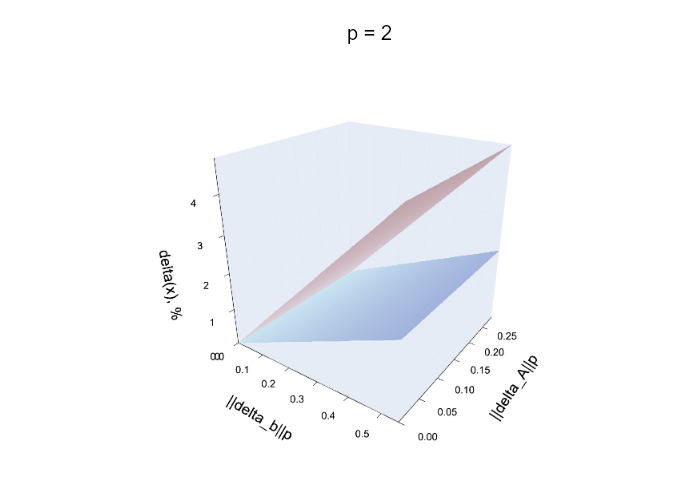

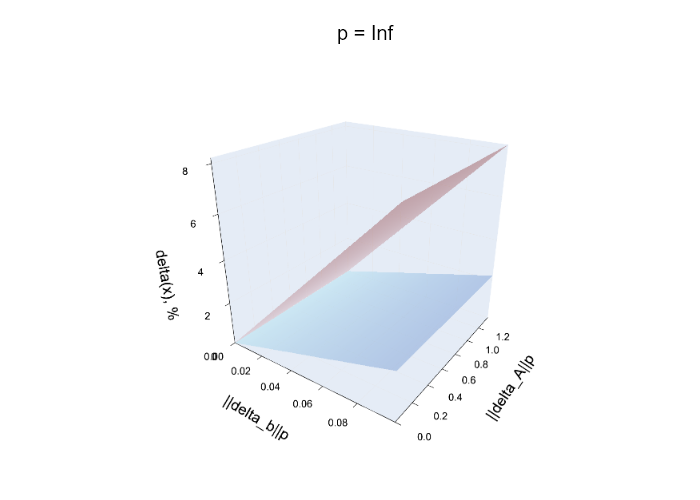

In [2]:
# СОЗДАНИЕ ДАННЫХ ДЛЯ ГРАФИКА
function buildSurfaces(A, b, delta_A, delta_b, p)
    x = solveSystem(A, b)
    nu = condNumber(A, p)
    
    # Изменение возмущений от 0 до полного значения
    scale = collect(0.00:0.05:1.00)
    count = length(scale)

    xAxis = zeros(count)
    yAxis = zeros(count)

    directSurf = zeros(count, count)
    estimateSurf = zeros(count, count)
    # Значения для оси X
    for j in eachindex(scale)
        cur_b = scale[j] * delta_b
        xAxis[j] = norm(cur_b, p)
    end
    # Значения для оси Y
    for i in eachindex(scale)
        cur_A = scale[i] * delta_A
        yAxis[i] = opnorm(cur_A, p)
    end
    # Вычисление значений двух поверхностей
    for i in eachindex(scale)
        cur_A = scale[i] * delta_A
        for j in eachindex(scale)
            cur_b = scale[j] * delta_b
            xNew = solveSystem(A + cur_A,b + cur_b)
            delta_x = xNew - x
            directSurf[i, j] = round((norm(delta_x, p) / norm(x, p)) * 100.00, digits = 2)
            estimateSurf[i, j] = round(nu * (norm(cur_b, p) / norm(b, p) + opnorm(cur_A, p) / opnorm(A, p)) * 100.00, digits = 2)
        end
    end

    return (xAxis, yAxis, directSurf, estimateSurf)
end

# ПОСТРОЕНИЕ ГРАФИКА
function makeGraph(A, b, delta_A, delta_b, p)
    xAxis, yAxis, directSurf, estimateSurf = buildSurfaces(A, b, delta_A, delta_b, p)

    if p == Inf
        pName = "Inf"
    else
        pName = "2"
    end

    graph = surface(
        xAxis, 
        yAxis, 
        directSurf,
        xlabel = "||delta_b||p",
        ylabel = "||delta_A||p",
        zlabel = "delta(x), %",
        title = "p = " * pName,
        label = "Прямой расчет",
        c = :blues,
        seriesalpha = 0.75,
        colorbar = false,
        camera = (35, 25),
        size = (900, 650)
    )

    surface!(
        graph,
        xAxis,
        yAxis,
        estimateSurf,
        label = "Оценка",
        c = :reds,
        seriesalpha = 0.55,
        colorbar = false
    )

    return graph
end

# ГРАФИК ДЛЯ p = 2
graph2 = makeGraph(A, b, delta_A, delta_b, 2)

# ГРАФИК ДЛЯ p = Inf
graphInf = makeGraph(A, b, delta_A, delta_b, Inf)

# ВЫВОД ГРАФИКОВ
display(graph2)
display(graphInf)